In [8]:
import os
import cv2
import numpy as np
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
import matplotlib.pyplot as plt
from sklearn.metrics import (accuracy_score,f1_score,confusion_matrix,classification_report)

In [9]:
X = []
Y = []

img_size = 128

# Dataset path
base_path = "/kaggle/input/datasets/sartajbhuvaji/brain-tumor-classification-mri/Training"

classes = {
    'no_tumor': 0,
    'pituitary_tumor': 1,
    'glioma_tumor': 2,
    'meningioma_tumor': 3
}



In [10]:
for cls, label in classes.items():

    path = os.path.join(base_path, cls)

    for filename in os.listdir(path):

        img_path = os.path.join(path, filename)

        # Read image
        img = cv2.imread(img_path)

        # Skip corrupted images
        if img is None:
            continue

        # Resize image
        img = cv2.resize(img, (img_size, img_size))

        # Convert BGR to RGB
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        # Normalize image
        img = img.astype('float32') / 255.0

        # Flatten image for XGBoost
        img = img.flatten()

        # Store
        X.append(img)
        Y.append(label)
        
X = np.array(X)
Y = np.array(Y)

print("X shape :", X.shape)
print("Y shape :", Y.shape)

X shape : (2870, 49152)
Y shape : (2870,)


In [11]:
X_train, X_test, y_train, y_test = train_test_split(

    X,
    Y,

    test_size = 0.2,

    random_state = 42,

    stratify = Y
)

print("\nTraining Samples :", X_train.shape[0])
print("Testing Samples  :", X_test.shape[0])


Training Samples : 2296
Testing Samples  : 574


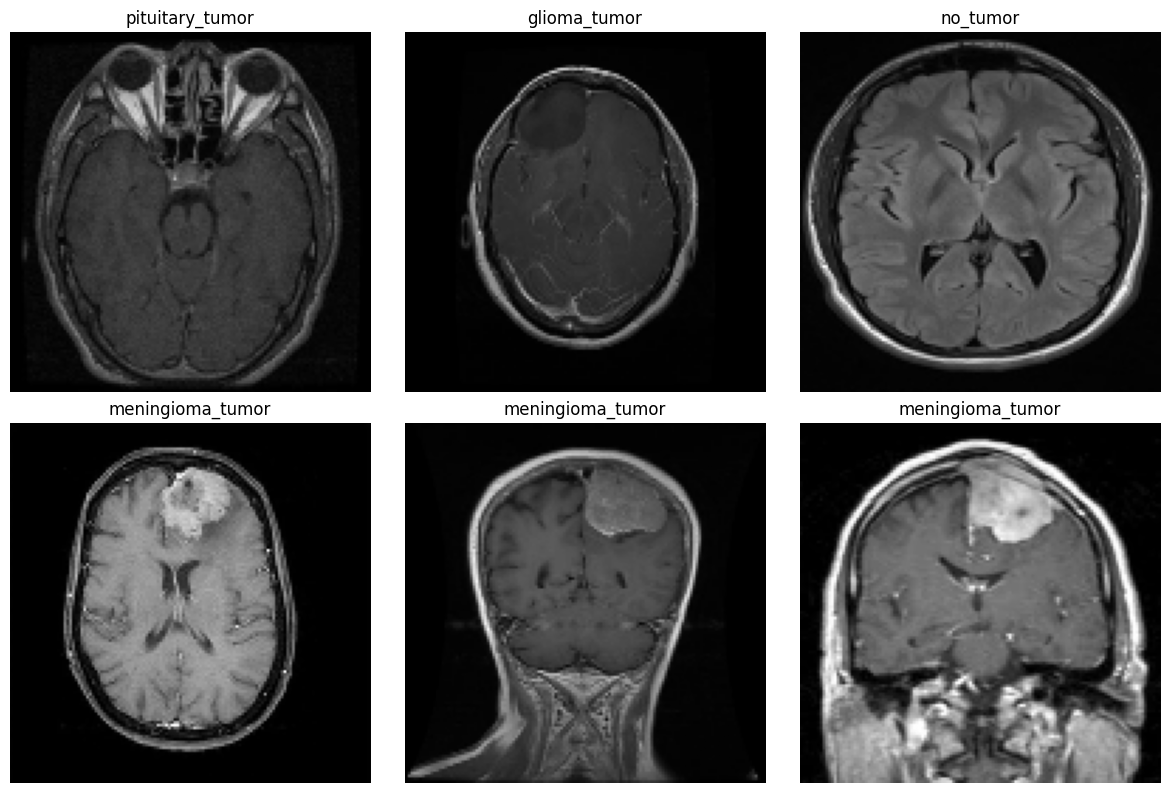

In [12]:
class_names = list(classes.keys())

plt.figure(figsize=(12,8))

for i in range(6):

    plt.subplot(2,3,i+1)

    img = X_train[i].reshape(img_size, img_size, 3)

    plt.imshow(img)

    plt.title(class_names[y_train[i]])

    plt.axis('off')

plt.tight_layout()
plt.show()

In [13]:
xgb_model = XGBClassifier(

    n_estimators = 100,

    max_depth = 6,

    learning_rate = 0.1,

    objective = 'multi:softmax',

    num_class = 4,

    eval_metric = 'mlogloss',

    random_state = 42
)

In [14]:
print("\nTraining XGBoost Model...\n")

xgb_model.fit(X_train, y_train)
y_pred = xgb_model.predict(X_test)


Training XGBoost Model...



In [15]:
# Accuracy
accuracy = accuracy_score(y_test, y_pred)

# F1 Score
f1 = f1_score(y_test, y_pred, average='weighted')

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sensitivity_list = []
specificity_list = []

for i in range(len(classes)):

    TP = cm[i, i]

    FN = np.sum(cm[i, :]) - TP

    FP = np.sum(cm[:, i]) - TP

    TN = np.sum(cm) - (TP + FP + FN)

    sensitivity = TP / (TP + FN)

    specificity = TN / (TN + FP)

    sensitivity_list.append(sensitivity)

    specificity_list.append(specificity)

# Average sensitivity and specificity
avg_sensitivity = np.mean(sensitivity_list)

avg_specificity = np.mean(specificity_list)

In [16]:
print("\n===================================================")
print("      BRAIN TUMOR CLASSIFICATION RESULTS")
print("===================================================\n")

print(f"Accuracy      : {accuracy*100:.2f}%")

print(f"F1-Score      : {f1:.4f}")

print(f"Sensitivity   : {avg_sensitivity:.4f}")

print(f"Specificity   : {avg_specificity:.4f}")

print("\n===================================================")
print("Classification Report")
print("===================================================\n")

print(classification_report(
    y_test,
    y_pred,
    target_names=class_names
))

print("\n===================================================")
print("Confusion Matrix")
print("===================================================\n")

print(cm)


      BRAIN TUMOR CLASSIFICATION RESULTS

Accuracy      : 90.24%
F1-Score      : 0.9024
Sensitivity   : 0.9068
Specificity   : 0.9666

Classification Report

                  precision    recall  f1-score   support

        no_tumor       0.90      0.94      0.92        79
 pituitary_tumor       0.93      0.96      0.94       166
    glioma_tumor       0.94      0.87      0.90       165
meningioma_tumor       0.84      0.86      0.85       164

        accuracy                           0.90       574
       macro avg       0.90      0.91      0.90       574
    weighted avg       0.90      0.90      0.90       574


Confusion Matrix

[[ 74   1   0   4]
 [  1 159   3   3]
 [  0   2 144  19]
 [  7   9   7 141]]


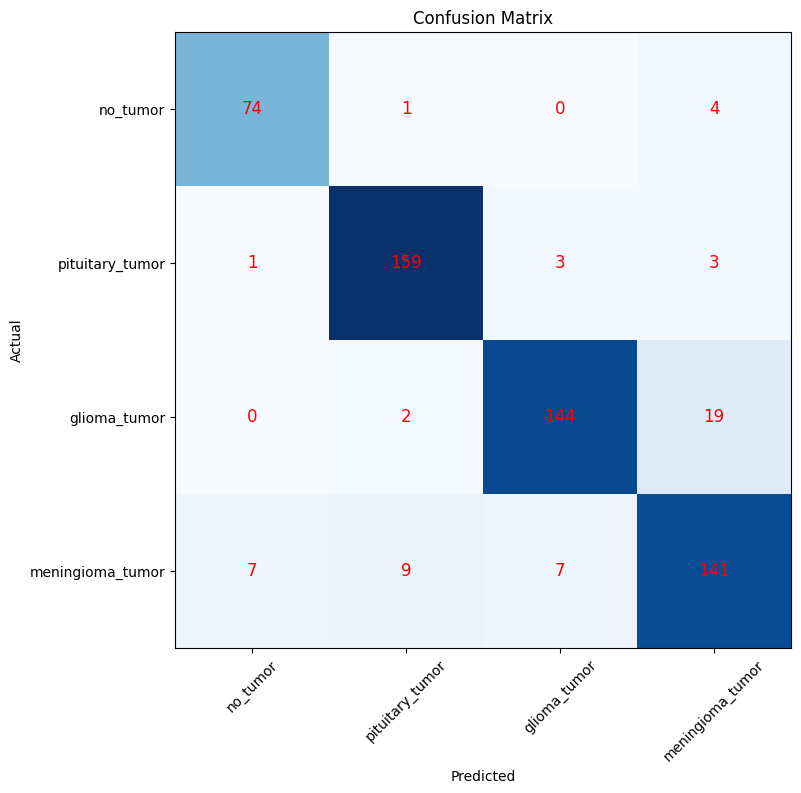

In [17]:
plt.figure(figsize=(8,8))

plt.imshow(cm, cmap='Blues')

plt.title("Confusion Matrix")

plt.xticks(range(len(classes)), class_names, rotation=45)

plt.yticks(range(len(classes)), class_names)

for i in range(len(classes)):
    for j in range(len(classes)):

        plt.text(
            j,
            i,
            cm[i, j],
            ha='center',
            va='center',
            color='red',
            fontsize=12
        )

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()